In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
from scipy.stats import unitary_group
import time
import matplotlib.pyplot as plt
import tracemalloc



# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

S_plus = (S_X+1j*S_Y)/2
S_minus = (S_X-1j*S_Y)/2

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')



def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod

# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q
    return q



To-do's:
1. fix unitary
2. clarify turning on the field in the bulk with Markovian channel
3. since n=2, q can be arbitrary. Find the rate/mass/magnetic field under which there is a volume law.

In [68]:
def mkJumpLiouv(rate, dt, ldbldOp):

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)

    lindblads = [L1,L2]

    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))

    denseU=linalg.expm(G * dt)

    return denseU # to act on the vectorized density matrix of 2 qubits

def mkHaarLiouv(dt):
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    denseU=linalg.expm( -1j * H * dt)
    
    return denseU


def mkKrausOps(U):
    # takes outputs from mkLiouv
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))
    [eigVals, eigVecs] = linalg.eigh(X)

    krausOps=[]

    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]

    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    # every row stores the 16 overlap between the Kraus ops with the 16 basis Paulis
    k_abs=np.array([[] for i in range(16)], dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4), dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op) # Always real
        k_abs = np.vstack([k_abs,k_temp])
    binaryMat = abs(np.array(k_abs).astype(float))>1e-10

    # k_abs sparse for jumps but dense for unitaries
    return k_abs*binaryMat


def mkUnitaryKrausOps(layer, Nqubit, debug=False):

    allKs = {}
    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            # first unitary:
            krausOps = [unitary_group.rvs(4)]
            allKs[pos] = []

            U_chain = chain(repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
            allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = [unitary_group.rvs(4)]
            allKs[pos] = []

            if pos < Nqubit-1:                
                U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC

                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]
    return allKs


# Just make a separate function for jumps:
def mkJumpKrausOps(layer, Nqubit, dt2, rate, ldbldOp, debug=False):       
    allKs = {}
    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            # first unitary:
            krausOps = mkKrausOps(mkJumpLiouv(rate, dt2, ldbldOp))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = mkKrausOps(mkJumpLiouv(rate, dt2, ldbldOp))
            allKs[pos] = []

            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC
                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]
                    
    print(allKs)
    return allKs


# employ the faster Kraus sum
def evolveKrausU(allKs, rho, debug = False):
    #tracemalloc.start()
    Nqubit = int(np.log2(len(rho.toarray())))

    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()
    
    #print('Unitary costs '+ str(tracemalloc.get_traced_memory()))
    #tracemalloc.stop()
    return newRho



def mkS_zMsm(probMsm, rho , debug = False):

    Nqubit = int(np.log2(len(rho.toarray())))
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2,
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)

        for (j,ms) in enumerate(msmSites):
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)

            if debug == True: print(proj_chain)

            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            if debug == True: print("projector", proj0p.shape, " rho", rho.shape)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())

            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob

            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            rho = testRho

    else:
        testRho = rho

    return testRho


def ptrace_rho(rho, elements):
    operator = rho
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    temp = np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

    elems = set(elements)
    counter = 0
    indexarr = []
    for i in range(len(temp.shape)//2):
        if i in elems:
            indexarr += [counter,counter]
            counter += 1
        else:
            indexarr += [counter,counter+1]
            counter += 2
    operator = np.einsum(temp, indexarr)

    length = len(operator.shape)
    halflength = length//2

    if elements != []:
        operator = np.transpose(operator,[length-2,length-1]+list(range(0,length-2))) #cyclic permutation for toqito

    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))


def calcS(densityM, partiesToTraceOut):
    Ntot=int(np.log2(densityM.shape[0]))
    redRho = ptrace_rho(densityM, partiesToTraceOut)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S


def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity

def flatten_tensor_op(operator):
    length = len(operator.shape)
    halflength = length//2
    reorder = np.transpose(operator,[2*n for n in range(0,halflength)]+[2*n+1 for n in range(0,halflength)])
    return np.reshape(reorder, (np.prod(operator.shape[::2]), np.prod(operator.shape[1::2])))

#only works for tensor products of 2-state systems
def unflatten_tensor_op(operator):
    halflength = int(np.log2(operator.shape[0]))
    reorder = np.reshape(operator, (2,)*(2*halflength))
    return np.transpose(reorder, [n//2+halflength*(n%2) for n in range(0,halflength*2)])

def calcNegativity(densitymatx, transpose_indices):
    unflatrho = unflatten_tensor_op(densitymatx)
    transposer = list(range(len(unflatrho.shape)))
    for i in transpose_indices:
        transposer[2*i+1],transposer[2*i] = transposer[2*i],transposer[2*i+1]
    transposed = flatten_tensor_op(np.transpose(unflatrho,tuple(transposer)))
    return (np.trace(linalg.sqrtm(transposed.T.conj()@transposed))-1)/2

def combinedRoutine_1(initRho, Nqubit, rate, probMs, dt2, jumpOp, steps, debug = False):
    rho = sparse.csr_matrix(reduce(sparse.kron, [initRho]*Nqubit))

    startTime = time.time()
    print('traj starts.')

    entropy1 = np.zeros(steps)
    entropy2 = np.zeros(steps)
    entropy_tot = np.zeros(steps)
    mutual_info = np.zeros(steps)
    purity = np.zeros(steps)
    negativity = np.zeros(steps)

    # pre-make all the Kraus operators so it's not calculated all the time
    evenJumpKrausOps = mkJumpKrausOps(2, Nqubit,  dt2, rate, jumpOp, debug = False)
    oddJumpKrausOps =  mkJumpKrausOps(1, Nqubit,  dt2, rate, jumpOp, debug = False)

    for s in range(steps):
        # first evolve unitary
        allKrausOps = mkUnitaryKrausOps(s, Nqubit, debug = False)
        rho = evolveKrausU(allKrausOps, rho)

        # second Jump,
        if s % 2 == 0:
            allKrausOps = evenJumpKrausOps
        else:
            allKrausOps = oddJumpKrausOps
        rho = evolveKrausU(allKrausOps, rho)

        # third mk msm...
        rho = mkS_zMsm(probMs, rho)


        entropy1[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
        entropy2[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
        entropy_tot[s] = calcS(rho.toarray(), partiesToTraceOut = [])
        mutual_info[s] = entropy1[s] + entropy2[s] - entropy_tot[s]
        purity[s] = np.real(calcPurity(rho.toarray()))
        negativity[s] = calcNegativity(rho.toarray(), [n for n in range(Nqubit//2)])

        del allKrausOps

    del rho
    return entropy1, entropy2, entropy_tot, mutual_info, purity, negativity

def evolveUnitary(layer, rho, Nqubit, debug=False):
    #tracemalloc.start()
    
    # convert rho back to normal matrix
    rho = rho.toarray()
    #allKs = {}
    if np.mod(layer,2) == 0:
        # position records every other sites that goes thru 2 qubit unitaries
        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:
            krausOps = [unitary_group.rvs(4)]
            U_chain = chain(repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
            mat = reduce(np.kron, U_chain)

            # Evolve
            rho = mat @ rho @ mat.T.conj()

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = [unitary_group.rvs(4)]

            if pos < Nqubit-1:
                U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), krausOps, repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                mat = reduce(sparse.kron, U_chain)
                rho = mat @ rho @ mat.T.conj()

            else:
                # decompose the Kraus ops on the edges
                k_abs = decompKrausOps(krausOps)
                
                # reconstruct all the Kraus ops with shifted basis
                for row in k_abs:
                    
                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4] # Unitary at pos 1
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] # Unitary at pos 2

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    # Now evolve with the Kraus
                    rho = K_jk @ rho @ K_jk.T.conj()
    #print('Unitary costs '+ str(tracemalloc.get_traced_memory()))
    #tracemalloc.stop()
    return rho



def combinedRoutine_2(initRho, Nqubit, rate, probMs, dt2, jumpOp, steps, debug = False):
    rho = sparse.csr_matrix(reduce(sparse.kron, [initRho]*Nqubit))

    startTime = time.time()
    print('traj starts.')
    tracemalloc.start()


    entropy1 = np.zeros(steps)
    entropy2 = np.zeros(steps)
    entropy_tot = np.zeros(steps)
    mutual_info = np.zeros(steps)
    purity = np.zeros(steps)
    negativity = np.zeros(steps)

    # pre-make all the Kraus operators so it's not calculated all the time
    evenJumpKrausOps = mkJumpKrausOps(2, Nqubit,  dt2, rate, jumpOp, debug = False)
    oddJumpKrausOps =  mkJumpKrausOps(1, Nqubit,  dt2, rate, jumpOp, debug = False)

    for s in range(steps):
        # first evolve unitary
        rho = evolveUnitary(s, rho, Nqubit)

        # second Jump,
        if s % 2 == 0:
            allKrausOps = evenJumpKrausOps
        else:
            allKrausOps = oddJumpKrausOps
        rho = evolveKrausU(allKrausOps, sparse.csr_matrix(rho))

        # third mk msm...
        rho = mkS_zMsm(probMs, rho)


        entropy1[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(0, Nqubit//2-1)))
        entropy2[s] = calcS(rho.toarray(), partiesToTraceOut = list(range(Nqubit//2, Nqubit)))
        entropy_tot[s] = calcS(rho.toarray(), partiesToTraceOut = [])
        mutual_info[s] = entropy1[s] + entropy2[s] - entropy_tot[s]
        purity[s] = np.real(calcPurity(rho.toarray()))
        negativity[s] = calcNegativity(rho.toarray(), [n for n in range(Nqubit//2)])

        del allKrausOps

    del rho
    return entropy1, entropy2, entropy_tot, mutual_info, purity, negativity


In [69]:
dt2 = 5 # so 1/5, twice, and 10 times larger than dt2
steps_N = 150 #int(t_total/(dt1+dt2))
jumpOp_global = S_Z
p = 0.15
r = 1e-1
N = 6
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

startTime = time.time()
print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

S1, S2, Stot, mutualInfo_1, purity_1, negativity_1 = combinedRoutine_1(
                            initRho = state0rho,
                            Nqubit = N,
                            rate = r,
                            probMs = p,
                            dt2 = dt2,                                                                                     
                            jumpOp = jumpOp_global,
                            steps = steps_N,
                            debug = False)
#print(S1, S2, Stot, mutualInfo, purity, negativity)
print('costs '+ str(tracemalloc.get_traced_memory()))
tracemalloc.stop()
print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


startTime = time.time()
print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')

print('evolve unitarily for', dt1, 's; dissipate for',dt2, 's.')
S1, S2, Stot, mutualInfo_2, purity_2, negativity_2 = combinedRoutine_2(
                            initRho = state0rho,
                            Nqubit = N,
                            rate = r,
                            probMs = p,
                            dt2 = dt2,                                                                                     
                            jumpOp = jumpOp_global,
                            steps = steps_N,
                            debug = False)
#print(S1, S2, Stot, mutualInfo, purity, negativity)

print('run time for probability ', str(p), ' =', time.time()-startTime, flush=True)


evolve unitarily for 5 s; dissipate for 5 s.
traj starts.
{0: [<64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 112 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>], 2: [<64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 112 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>], 4: [<64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored ele

/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:320: ComplexWarning: Casting complex values to real discards the imaginary part


costs (0, 0)
run time for probability  0.15  = 6.651442050933838
evolve unitarily for 5 s; dissipate for 5 s.
evolve unitarily for 5 s; dissipate for 5 s.
traj starts.
{0: [<64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 112 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>], 2: [<64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 112 stored elements in COOrdinate format>, <64x64 sparse matrix of type '<class 'numpy.complex128'>'
	with 80 stored elem

/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:419: ComplexWarning: Casting complex values to real discards the imaginary part


run time for probability  0.15  = 10.610465049743652


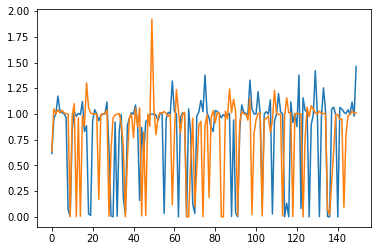

In [64]:
plt.plot(mutualInfo_1)
plt.plot(mutualInfo_2)

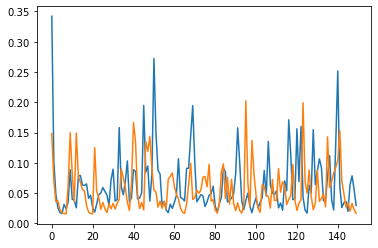

In [66]:
plt.plot(purity_1)
plt.plot(purity_2)

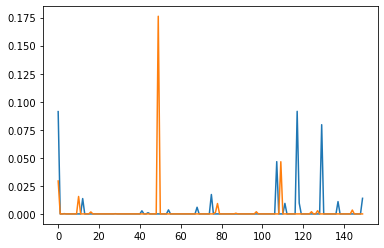

In [67]:
plt.plot(negativity_1)
plt.plot(negativity_2)

In [81]:
K_s = mkJumpKrausOps(1, 10, 5, 0.5, jumpOp_global, debug=False)      


/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:48: ComplexWarning: Casting complex values to real discards the imaginary part


{1: [<1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 2560 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 3584 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 3584 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 3072 stored elements (blocksize = 2x2) in Block Sparse Row format>], 3: [<1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 2560 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 3584 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<class 'numpy.complex128'>'
	with 3584 stored elements (blocksize = 2x2) in Block Sparse Row format>, <1024x1024 sparse matrix of type '<cla

In [83]:
[key for key in K_s.keys()]

[1, 3, 5, 7, 9]

In [88]:
np.arctan((5/(np.sqrt(10)-2)-1)**(1/4))

0.932539385479594

In [90]:
np.sin(0.932539385479594)**2

0.6450266081863637